# 2장 실습 — 지연의 출처

1장에서 마감을 세웠다. 이제 그 마감을 무엇이 먹는지 나눠 본다.

「추론이 30 밀리초」라고 말할 때 대개 **모델의 순전파**만 잰 것이다. 실제 제어 고리에는 그 앞뒤로 관측 획득, 전처리, 후처리, 명령 전송이 붙는다. Physical Intelligence가 자기 로봇에서 잰 분해를 보면 모바일 매니퓰레이터의 한 주기 139 밀리초 가운데 모델이 97, 네트워크가 21, 이미지 리사이즈가 11, 나머지가 9.7이었다. **모델이 70%였다.**

이 노트북은 그 분해를 직접 만든다. 그리고 **지배적인 단계가 모델 크기에 따라 바뀐다**는 것을 본다.

실행 시간은 CPU에서 3분 안팎이다.

In [1]:
%pip install -q koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("torch", torch.__version__,
      "/ 스레드", torch.get_num_threads())

torch 2.14.0+cu130 / 스레드 2


## 고리를 다섯 조각으로 자른다

실기 제어 고리를 단계로 적으면 이렇다.

1. **관측 획득** — 카메라에서 프레임을 받고 관절 상태를 읽는다
2. **전처리** — 이미지를 모델 입력 크기로 줄이고 정규화한다
3. **추론** — 모델 순전파
4. **후처리** — 정규화를 되돌리고 한계로 자르고 안전 검사를 한다
5. **명령 전송** — 구동기에 보낸다

이 노트북은 1~4를 **실제로 돌려서** 잰다. 5는 이 환경에 버스도 네트워크도 없으므로 재지 않고, 대신 문헌의 실측치를 이론 장에서 인용한다. **재지 못한 것을 지어내지 않는 것**이 3권부터의 규칙이다.

In [3]:
H, W = 480, 640            # 카메라 원본
S = 224                    # 모델 입력


def grab(rng):
    """카메라 프레임 한 장 — uint8 HWC"""
    return rng.integers(0, 255, (H, W, 3), dtype=np.uint8)


def preprocess(img):
    """최근접 이웃 축소 + 정규화 + CHW 배치"""
    yi = np.arange(S) * H // S
    xi = np.arange(S) * W // S
    small = img[yi][:, xi]
    x = small.astype(np.float32) / 255.
    x = (x - .45) / .225
    return torch.from_numpy(x.transpose(2, 0, 1))[None]


def postprocess(a):
    """정규화 되돌리기 + 한계 자르기 + 간단한 안전 검사"""
    u = np.clip(a.numpy().ravel(), -1., 1.) * .35
    if not np.isfinite(u).all():
        u = np.zeros_like(u)
    return u

## 세 가지 크기의 정책

같은 고리에 모델만 갈아 끼운다.

- **상태 MLP** — 3권에서 쓴 정책이다. 8차원 상태를 받는 64-64 MLP
- **작은 CNN** — 이미지를 받는 합성곱 인코더 + MLP 머리
- **트랜스포머** — 16×16 패치 196개, 폭 192, 층 6개. VLA의 시각 탑을 아주 작게 줄인 것이다

In [4]:
class StateMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3, 16, 5, 4, 2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


class TinyViT(nn.Module):
    def __init__(self, dim=192, depth=6, heads=3):
        super().__init__()
        self.patch = nn.Conv2d(3, dim, 16, 16)
        self.pos = nn.Parameter(torch.zeros(1, (S // 16) ** 2, dim))
        layer = nn.TransformerEncoderLayer(
            dim, heads, dim * 4, batch_first=True,
            norm_first=True, dropout=0.)
        self.enc = nn.TransformerEncoder(
            layer, depth, enable_nested_tensor=False)
        self.head = nn.Linear(dim, 2)

    def forward(self, x):
        z = self.patch(x).flatten(2).transpose(1, 2) + self.pos
        return self.head(self.enc(z).mean(1))


MODELS = {}
for name, cls in (("상태 MLP", StateMLP), ("작은 CNN", SmallCNN),
                  ("트랜스포머", TinyViT)):
    m = cls().eval()
    MODELS[name] = m
    n = sum(p.numel() for p in m.parameters())
    print(pad(name, 14) + pad(f"{n:,} 파라미터", 20, True))

상태 MLP            4,866 파라미터
작은 CNN           28,642 파라미터
트랜스포머      2,854,850 파라미터


## 구간을 나눠 잰다

`perf_counter_ns` 로 네 구간을 각각 재고, 워밍업 판은 버린다. 첫 몇 판은 메모리 할당과 커널 선택 때문에 느려서, 그것을 섞으면 꼬리가 가짜로 부풀어 오른다.

In [5]:
def profile(name, reps=120, warm=20):
    model = MODELS[name]
    rng = np.random.default_rng(0)
    state = torch.randn(1, 8)
    rec = {k: [] for k in ("관측", "전처리", "추론", "후처리")}
    for i in range(reps + warm):
        t0 = time.perf_counter_ns()
        img = grab(rng)
        t1 = time.perf_counter_ns()
        x = state if name == "상태 MLP" else preprocess(img)
        t2 = time.perf_counter_ns()
        with torch.no_grad():
            a = model(x)
        t3 = time.perf_counter_ns()
        postprocess(a)
        t4 = time.perf_counter_ns()
        if i < warm:
            continue
        for k, v in zip(rec, (t1 - t0, t2 - t1, t3 - t2, t4 - t3)):
            rec[k].append(v / 1e6)
    return {k: np.array(v) for k, v in rec.items()}


t0 = time.time()
PROF = {k: profile(k) for k in MODELS}
print(f"계측 끝  ({time.time() - t0:.0f}s)")

계측 끝  (3s)


In [6]:
HEAD = (pad("모델", 14) + pad("관측", 9, True)
        + pad("전처리", 9, True) + pad("추론", 9, True)
        + pad("후처리", 9, True))
print(HEAD + pad("합계", 9, True))
for name, r in PROF.items():
    tot = sum(v.mean() for v in r.values())
    print(pad(name, 14)
          + "".join(pad(f"{v.mean():.1f}", 9, True)
                    for v in r.values())
          + pad(f"{tot:.1f}", 9, True))
print()
print("단위는 ms")

모델               관측   전처리     추론   후처리     합계
상태 MLP            2.7      0.0      0.1      0.0      2.8
작은 CNN            2.7      0.6      1.0      0.1      4.4
트랜스포머          2.6      0.6     11.9      0.1     15.2

단위는 ms


## 지배적인 단계가 바뀐다

같은 숫자를 비율로 다시 적는다.

In [7]:
print(HEAD)
for name, r in PROF.items():
    tot = sum(v.mean() for v in r.values())
    print(pad(name, 14)
          + "".join(pad(f"{v.mean() / tot * 100:.0f}%", 9, True)
                    for v in r.values()))

모델               관측   전처리     추론   후처리
상태 MLP            95%       0%       4%       1%
작은 CNN            62%      14%      23%       1%
트랜스포머          17%       4%      78%       1%


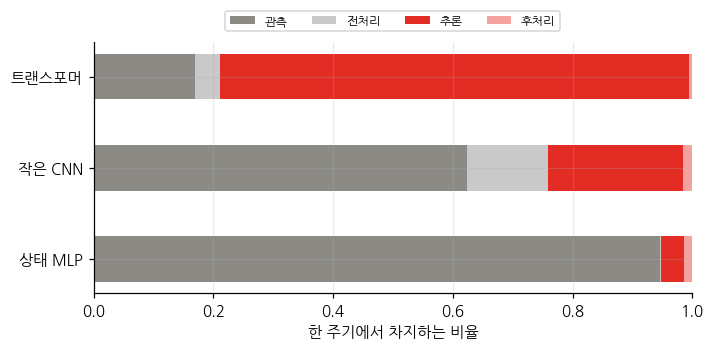

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
names = list(PROF)
keys = ["관측", "전처리", "추론", "후처리"]
cols = [GREY, "#C9C9C9", RED, PINK]
bottom = np.zeros(len(names))
for k, c in zip(keys, cols):
    v = np.array([PROF[n][k].mean() / sum(x.mean()
                  for x in PROF[n].values()) for n in names])
    ax.barh(names, v, left=bottom, color=c, label=k, height=.5)
    bottom += v
ax.set_xlim(0, 1)
ax.set_xlabel("한 주기에서 차지하는 비율")
ax.legend(fontsize=8, ncol=4, loc="lower center",
          bbox_to_anchor=(.5, 1.02))
plt.tight_layout()
plt.show()

## 꼬리는 어느 단계에서 오는가

1장에서 꼬리가 마감을 넘긴다고 했다. 그러면 그 꼬리가 어느 구간에서 생기는지 물어야 한다. 구간마다 p99를 p50으로 나눠 본다.

In [9]:
print(pad("모델", 14) + pad("구간", 10) + pad("p50", 9, True)
      + pad("p99", 9, True) + pad("p99/p50", 11, True))
for name, r in PROF.items():
    for k, v in r.items():
        p50 = np.percentile(v, 50)
        p99 = np.percentile(v, 99)
        ratio = f"{p99 / max(p50, 1e-9):.1f}배"
        print(pad(name, 14) + pad(k, 10)
              + pad(f"{p50:.2f}", 9, True)
              + pad(f"{p99:.2f}", 9, True)
              + pad(ratio, 11, True))

모델          구간            p50      p99    p99/p50
상태 MLP      관측           2.66     2.82      1.1배
상태 MLP      전처리         0.00     0.00      6.3배
상태 MLP      추론           0.10     0.22      2.3배
상태 MLP      후처리         0.04     0.07      1.9배
작은 CNN      관측           2.70     3.08      1.1배
작은 CNN      전처리         0.57     0.87      1.5배
작은 CNN      추론           0.94     1.68      1.8배
작은 CNN      후처리         0.06     0.13      2.2배
트랜스포머    관측           2.67     2.81      1.1배
트랜스포머    전처리         0.58     0.95      1.6배
트랜스포머    추론          11.70    15.90      1.4배
트랜스포머    후처리         0.07     0.12      1.7배


## 스레드를 줄이면

실기 온보드 컴퓨터에서 정책이 코어를 독차지하는 일은 드물다. 인식, 로깅, 통신, 안전 감시가 같은 칩에 올라와 있다. 트랜스포머의 추론만 스레드 수를 바꿔 가며 재 본다.

In [10]:
m = MODELS["트랜스포머"]
x = preprocess(grab(np.random.default_rng(0)))
print(pad("스레드", 10) + pad("p50 ms", 10, True)
      + pad("p99 ms", 10, True) + pad("1스레드 대비", 14, True))
base = None
for nt in (1, 2):
    torch.set_num_threads(nt)
    ts = []
    for i in range(60):
        t0 = time.perf_counter_ns()
        with torch.no_grad():
            m(x)
        if i >= 10:
            ts.append((time.perf_counter_ns() - t0) / 1e6)
    p50 = np.percentile(ts, 50)
    base = base or p50
    print(pad(f"{nt}", 10) + pad(f"{p50:.1f}", 10, True)
          + pad(f"{np.percentile(ts, 99):.1f}", 10, True)
          + pad(f"{base / p50:.2f}배", 14, True))
torch.set_num_threads(2)

스레드        p50 ms    p99 ms  1스레드 대비


1               17.8      21.3        1.00배


2               11.2      33.9        1.59배


## 정리

**모델은 고리의 일부다.** 실측 분해에서 모델이 70% 안팎이었고, 나머지 30%는 리사이즈·네트워크·기타였다. 모델만 재고 「30 밀리초」라고 보고하면 예산의 3할이 장부에서 빠진다.

**지배적인 단계는 모델 크기에 따라 바뀐다.** 상태 MLP에서는 프레임 획득이 거의 전부이고, 트랜스포머로 가면 추론이 지배한다. 무엇을 고칠지는 재 본 뒤에 정한다.

**꼬리는 평균이 큰 구간에서 오지 않을 수도 있다.** p99/p50 비가 큰 구간이 마감을 넘기는 범인이고, 그 구간은 대개 메모리를 새로 잡는 곳이다.

**온보드에서는 스레드가 자유롭지 않다.** 정책은 칩을 독차지하지 못한다.

다음 노트북은 이 숫자들을 **어떻게 보고할 것인가**를 정한다. 이 책이 열여섯 장 동안 쓸 규약이다.